In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
metadata_path = "HAM10000_metadata.csv"

images_path_1 = "HAM10000_images_part_1"

images_path_2 = "HAM10000_images_part_2"

In [3]:
df = pd.read_csv(metadata_path)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
image_paths = {}

for folder in [images_path_1, images_path_2]:
    for filename in os.listdir(folder):
        image_id = filename.replace(".jpg", "")
        image_paths[image_id] = os.path.join(folder, filename)

In [5]:
print("Total de imágenes:", len(image_paths))

Total de imágenes: 10017


In [6]:
df["path"] = df["image_id"].map(image_paths)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,HAM10000_images_part_1\ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,HAM10000_images_part_1\ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,HAM10000_images_part_1\ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,HAM10000_images_part_1\ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,HAM10000_images_part_2\ISIC_0031633.jpg


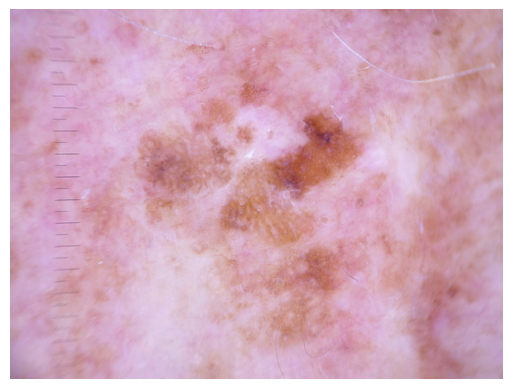

In [7]:
img = Image.open(df["path"][0])

plt.imshow(img)
plt.axis("off")
plt.show()

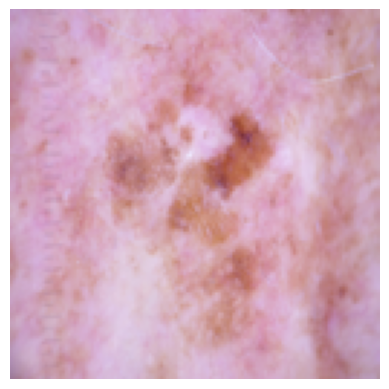

In [8]:
img = Image.open(df["path"][0])

img = img.resize((128, 128))

plt.imshow(img)
plt.axis("off")
plt.show()

In [9]:
img_array = np.array(img)

print(img_array.shape)

(128, 128, 3)


In [10]:
img_array = img_array / 255.0

print(img_array.min())
print(img_array.max())

0.19215686274509805
0.9882352941176471


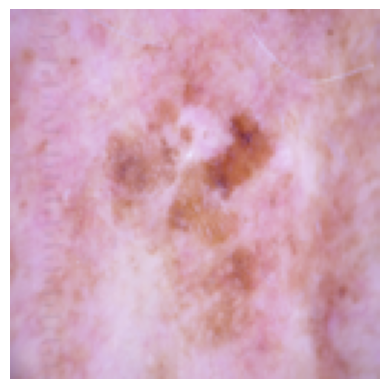

In [11]:
plt.imshow(img_array)
plt.axis("off")
plt.show()

In [12]:
processed_images = []

for path in df["path"]:
    img = Image.open(path)
    img = img.resize((128, 128))
    img = np.array(img) / 255.0
    processed_images.append(img)

In [13]:
processed_images = np.array(processed_images)

print(processed_images.shape)

(10015, 128, 128, 3)


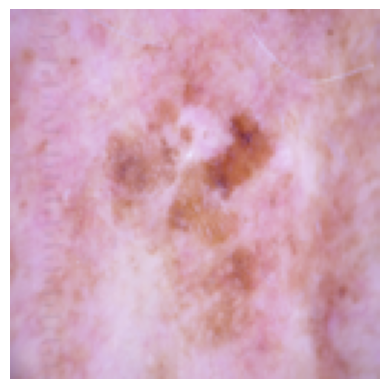

In [14]:
plt.imshow(processed_images[0])
plt.axis("off")
plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

labels = encoder.fit_transform(df["dx"])

print("Clases:", encoder.classes_)
print("Primeras etiquetas:", labels[:10])

Clases: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
Primeras etiquetas: [2 2 2 2 2 2 2 2 2 2]


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    processed_images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (8012, 128, 128, 3)
Prueba: (2003, 128, 128, 3)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(7, activation="softmax")
])

c:\Users\eugen\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=1,
    batch_size=32
)

201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 196ms/step - accuracy: 0.6575 - loss: 1.0982 - val_accuracy: 0.6762 - val_loss: 0.9117


In [21]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Accuracy en prueba:", test_acc)
print("Loss en prueba:", test_loss)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.6680 - loss: 0.9263
Accuracy en prueba: 0.6679980158805847
Loss en prueba: 0.9262973070144653


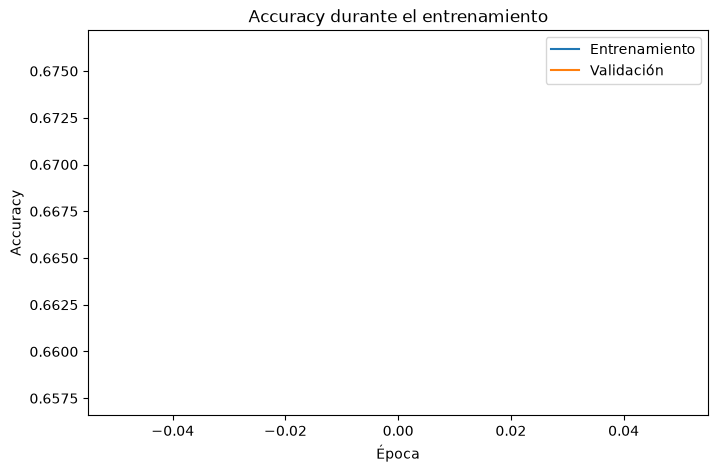

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')

plt.title("Accuracy durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [23]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 40s 195ms/step - accuracy: 0.6661 - loss: 0.9577 - val_accuracy: 0.6787 - val_loss: 0.9117
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 37s 185ms/step - accuracy: 0.6703 - loss: 0.9164 - val_accuracy: 0.6900 - val_loss: 0.8704
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 37s 183ms/step - accuracy: 0.6769 - loss: 0.8819 - val_accuracy: 0.6818 - val_loss: 0.8559
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 36s 181ms/step - accuracy: 0.6808 - loss: 0.8485 - val_accuracy: 0.7024 - val_loss: 0.7801
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 37s 185ms/step - accuracy: 0.6897 - loss: 0.8046 - val_accuracy: 0.7143 - val_loss: 0.7644
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 38s 190ms/step - accuracy: 0.6946 - loss: 0.7991 - val_accuracy: 0.7068 - val_loss: 0.7999
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 38s 190ms/step - accuracy: 0.7051 - loss: 0.7642 - val_accuracy: 0.7218 - val_loss: 0.7465
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 38s 189ms/step - accuracy: 0.7129 - loss: 0

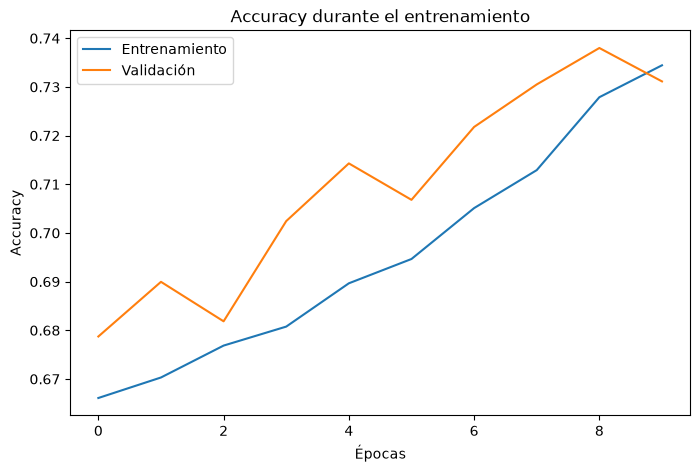

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")

plt.title("Accuracy durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

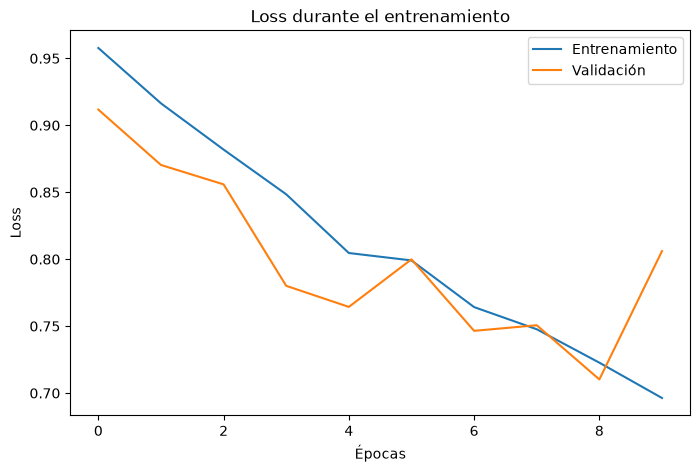

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")

plt.title("Loss durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [26]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.7164 - loss: 0.8558
Loss: 0.8557980060577393
Accuracy: 0.716425359249115


In [27]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step


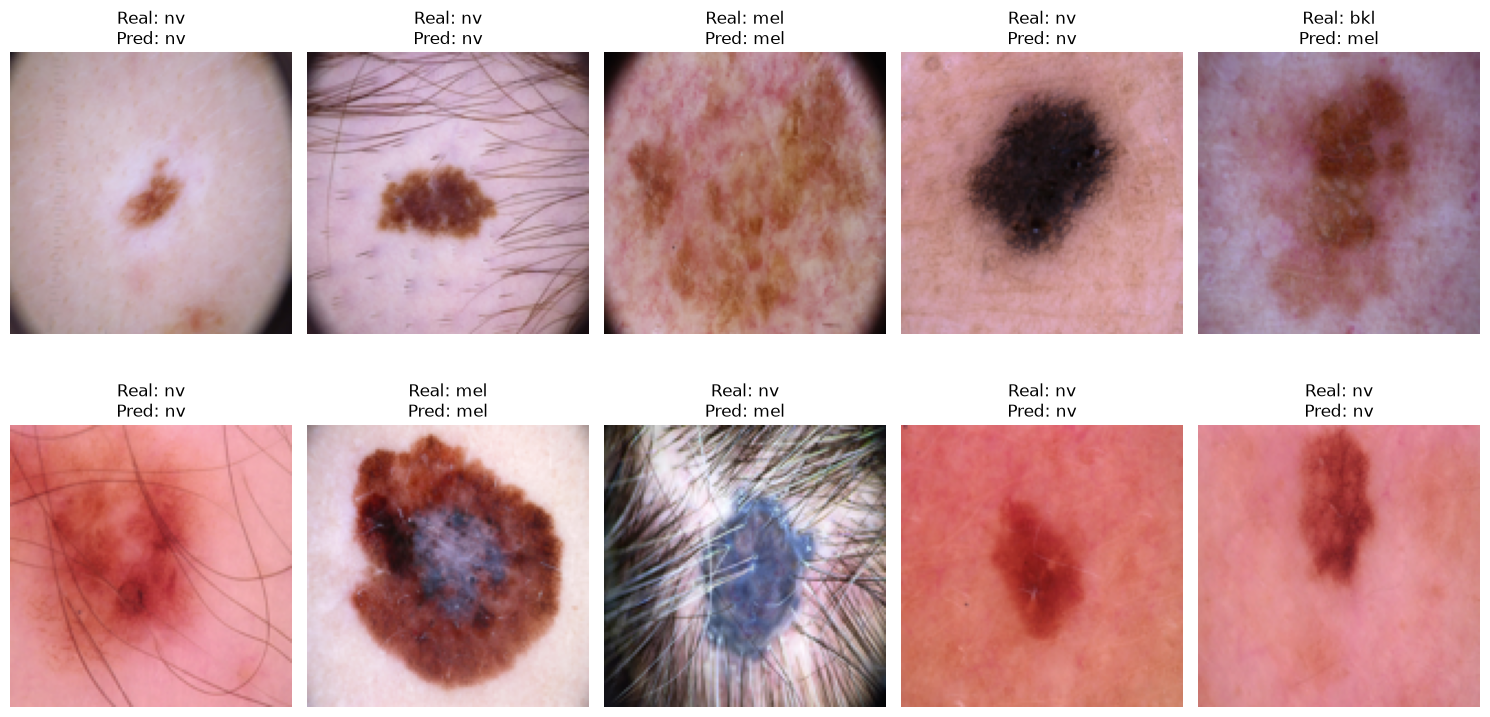

In [28]:
classes = encoder.classes_

plt.figure(figsize=(15,8))

for i in range(10):
    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i])

    real = classes[y_test[i]]
    pred = classes[predicted_labels[i]]

    plt.title(f"Real: {real}\nPred: {pred}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
model.save("modelo_ham10000.keras")

print("Modelo guardado correctamente.")

Modelo guardado correctamente.
